# Natural Language Processing (NLP) — Part 1

## Topics Covered

65. Text Pre-processing
    - Tokenization
    - Stopword Removal
    - Stemming
    - Lemmatization

66. Word Embeddings
    - Word2Vec
    - GloVe
    - Embedding Visualization

## Practical Work

- Clean and preprocess real text data
- Tokenize sentences
- Remove stopwords
- Apply stemming and lemmatization
- Create TF-IDF features
- Train Word2Vec embeddings
- Find similar words
- Visualize word embeddings

# Natural Language Processing

NLP is a branch of AI that allows computers to process and understand
human language.

Examples:

- Sentiment Analysis
- Text Classification
- Machine Translation
- Chatbots
- Text Summarization
- Named Entity Recognition
- Question Answering
- Text Generation

Basic NLP Pipeline:

Raw Text
   ↓
Text Preprocessing
   ↓
Tokenization
   ↓
Feature Extraction
   ↓
Machine Learning / Deep Learning
   ↓
Prediction

In [22]:
!pip install -q nltk gensim scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 27.5 MB/s eta 0:00:00


In [23]:
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

#Download NLTK Resources

In [24]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [25]:
text = """
Natural Language Processing allows computers to understand human language.
Machine learning models can analyze text, classify documents, and generate
useful information from large collections of documents.?/!@
"""

print(text)


Natural Language Processing allows computers to understand human language.
Machine learning models can analyze text, classify documents, and generate
useful information from large collections of documents.?/!@



#Convert to Lowercase

In [26]:
text_lower = text.lower()

print(text_lower)


natural language processing allows computers to understand human language.
machine learning models can analyze text, classify documents, and generate
useful information from large collections of documents.?/!@



#Remove Special Characters

In [27]:
clean_text = re.sub(
    r"[^a-zA-Z\s]",
    "",
    text_lower
)

print(clean_text)


natural language processing allows computers to understand human language
machine learning models can analyze text classify documents and generate
useful information from large collections of documents



# Tokenization

Tokenization splits text into smaller units called tokens.

Example:

"Machine learning is powerful"

↓

["Machine", "learning", "is", "powerful"]

In [28]:
tokens = word_tokenize(clean_text)

print(tokens)

['natural', 'language', 'processing', 'allows', 'computers', 'to', 'understand', 'human', 'language', 'machine', 'learning', 'models', 'can', 'analyze', 'text', 'classify', 'documents', 'and', 'generate', 'useful', 'information', 'from', 'large', 'collections', 'of', 'documents']


# Stopword Removal

Stopwords are very common words that may carry relatively little
information for some NLP tasks.

Examples:

- the
- is
- a
- an
- and
- of
- to

In [29]:
stop_words = set(
    stopwords.words("english")
)

filtered_tokens = [
    word
    for word in tokens
    if word not in stop_words
]

print(filtered_tokens)

['natural', 'language', 'processing', 'allows', 'computers', 'understand', 'human', 'language', 'machine', 'learning', 'models', 'analyze', 'text', 'classify', 'documents', 'generate', 'useful', 'information', 'large', 'collections', 'documents']


# Stemming

Stemming reduces words to a simpler root form by removing or modifying
word endings.

Examples:

playing → play
played → play
studies → studi

Stemming can produce words that are not proper dictionary words.

In [30]:
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_tokens
]

print(stemmed_words)

['natur', 'languag', 'process', 'allow', 'comput', 'understand', 'human', 'languag', 'machin', 'learn', 'model', 'analyz', 'text', 'classifi', 'document', 'gener', 'use', 'inform', 'larg', 'collect', 'document']


#Lemmatization

# Lemmatization

Lemmatization converts words to their meaningful dictionary base form.

Examples:

running → run
better → good
studies → study

Unlike simple stemming, lemmatization attempts to produce valid words.

In [31]:
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print(lemmatized_words)

['natural', 'language', 'processing', 'allows', 'computer', 'understand', 'human', 'language', 'machine', 'learning', 'model', 'analyze', 'text', 'classify', 'document', 'generate', 'useful', 'information', 'large', 'collection', 'document']


#Complete Preprocessing Function

In [32]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens

In [33]:
sample = """
I am learning Natural Language Processing.
NLP models are becoming very useful.
"""

print(preprocess_text(sample))

['learning', 'natural', 'language', 'processing', 'nlp', 'model', 'becoming', 'useful']


# Converting Text into Numbers

Machine learning models cannot directly process raw text.

Text must be converted into numerical features.

Common approaches:

1. Bag of Words
2. TF-IDF
3. Word Embeddings
4. Contextual Embeddings

In this module we will use TF-IDF and Word Embeddings.

# TF-IDF

TF-IDF stands for:

Term Frequency - Inverse Document Frequency

It gives higher importance to words that are important within a
document but less common across the entire collection.

TF-IDF is commonly used for text classification and information
retrieval.

In [34]:
documents = [
    "machine learning is powerful",
    "machine learning is useful",
    "natural language processing is powerful",
    "deep learning is useful",
    "natural language processing uses machine learning"
]

print(documents)

['machine learning is powerful', 'machine learning is useful', 'natural language processing is powerful', 'deep learning is useful', 'natural language processing uses machine learning']


#TF-IDF Vectorization

In [35]:
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(
    documents
)

print("Shape:", X_tfidf.shape)

Shape: (5, 10)


#View Vocabulary

In [36]:
print(
    vectorizer.get_feature_names_out()
)

['deep' 'is' 'language' 'learning' 'machine' 'natural' 'powerful'
 'processing' 'useful' 'uses']


#Convert to DataFrame

In [37]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df

,deep,is,language,learning,machine,natural,powerful,processing,useful,uses
0,0.000000,0.427809,0.000000,0.427809,0.508551,0.000000,0.612645,0.000000,0.000000,0.000000
1,0.000000,0.427809,0.000000,0.427809,0.508551,0.000000,0.000000,0.000000,0.612645,0.000000
2,0.000000,0.329635,0.472054,0.000000,0.000000,0.472054,0.472054,0.472054,0.000000,0.000000
3,0.661438,0.372642,0.000000,0.372642,0.000000,0.000000,0.000000,0.000000,0.533644,0.000000
4,0.000000,0.000000,0.418378,0.292153,0.347292,0.418378,0.000000,0.418378,0.000000,0.518569


#Word Embeddings

# Word Embeddings

Word embeddings represent words as dense numerical vectors.

Example:

king → [0.21, 0.54, -0.18, ...]

queen → [0.19, 0.51, -0.16, ...]

Words with similar meanings tend to have similar representations.

Popular methods:

- Word2Vec
- GloVe
- FastText

# Word2Vec

Word2Vec learns word representations from surrounding context.

Two common approaches:

CBOW
→ Predict the target word from surrounding words.

Skip-gram
→ Predict surrounding words from the target word.

#Prepare Corpus

In [38]:
sentences = [
    ["machine", "learning", "is", "powerful"],
    ["machine", "learning", "is", "useful"],
    ["deep", "learning", "is", "powerful"],
    ["natural", "language", "processing", "is", "useful"],
    ["natural", "language", "processing", "uses", "machine", "learning"],
    ["artificial", "intelligence", "uses", "machine", "learning"]
]

print(sentences)

[['machine', 'learning', 'is', 'powerful'], ['machine', 'learning', 'is', 'useful'], ['deep', 'learning', 'is', 'powerful'], ['natural', 'language', 'processing', 'is', 'useful'], ['natural', 'language', 'processing', 'uses', 'machine', 'learning'], ['artificial', 'intelligence', 'uses', 'machine', 'learning']]


#Train Word2Vec

In [39]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1
)

#Get Word Vector

In [40]:
vector = word2vec_model.wv["machine"]

print(vector)
print("Vector size:", len(vector))

[ 9.4563962e-05  3.0773198e-03 -6.8126451e-03 -1.3754654e-03
  7.6685809e-03  7.3464094e-03 -3.6732971e-03  2.6427018e-03
 -8.3171297e-03  6.2054861e-03 -4.6373224e-03 -3.1641065e-03
  9.3113566e-03  8.7338570e-04  7.4907029e-03 -6.0740625e-03
  5.1605068e-03  9.9228229e-03 -8.4573915e-03 -5.1356913e-03
 -7.0648370e-03 -4.8626517e-03 -3.7785638e-03 -8.5361991e-03
  7.9556061e-03 -4.8439382e-03  8.4236134e-03  5.2625705e-03
 -6.5500261e-03  3.9578713e-03  5.4701497e-03 -7.4265362e-03
 -7.4057197e-03 -2.4752307e-03 -8.6257253e-03 -1.5815723e-03
 -4.0343284e-04  3.2996845e-03  1.4418805e-03 -8.8142155e-04
 -5.5940580e-03  1.7303658e-03 -8.9737179e-04  6.7936908e-03
  3.9735902e-03  4.5294715e-03  1.4343059e-03 -2.6998555e-03
 -4.3668128e-03 -1.0320747e-03  1.4370275e-03 -2.6460087e-03
 -7.0737829e-03 -7.8053069e-03 -9.1217868e-03 -5.9351693e-03
 -1.8474245e-03 -4.3238713e-03 -6.4606704e-03 -3.7173224e-03
  4.2891586e-03 -3.7390434e-03  8.3781751e-03  1.5339935e-03
 -7.2423196e-03  9.43379

#Find Similar Words

In [41]:
similar_words = word2vec_model.wv.most_similar(
    "machine",
    topn=5
)

print(similar_words)

[('powerful', 0.1991206258535385), ('deep', 0.17272792756557465), ('processing', 0.17018842697143555), ('natural', 0.145950585603714), ('language', 0.06408977508544922)]


#Word Similarity

In [42]:
similarity = word2vec_model.wv.similarity(
    "machine",
    "learning"
)

print("Similarity:", similarity)

Similarity: -0.052346732


#Visualize Embeddings

In [43]:
from sklearn.decomposition import PCA

words = list(
    word2vec_model.wv.index_to_key
)

vectors = np.array([
    word2vec_model.wv[word]
    for word in words
])

pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(
    vectors
)

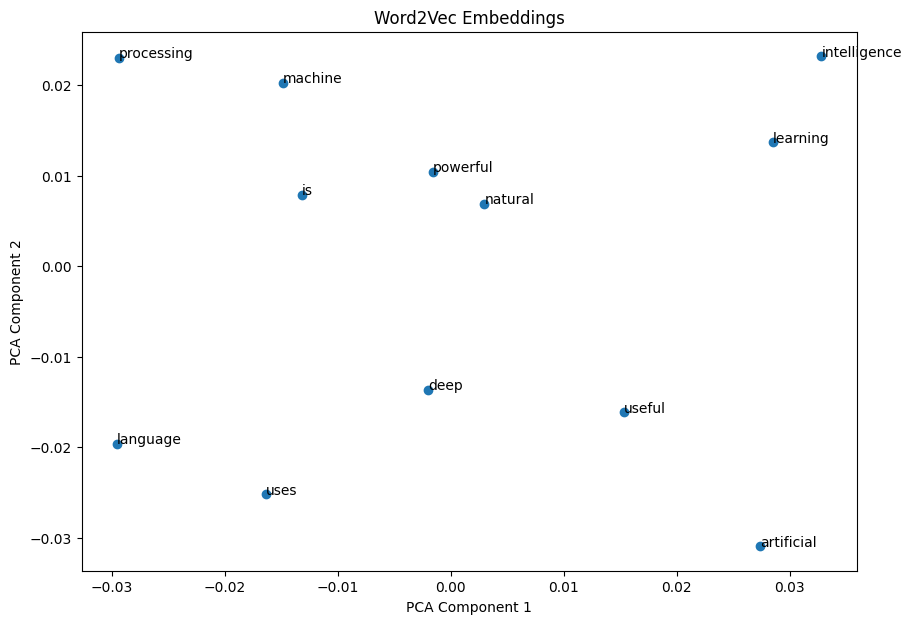

In [44]:
plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):

    plt.annotate(
        word,
        (
            vectors_2d[i, 0],
            vectors_2d[i, 1]
        )
    )

plt.title("Word2Vec Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Part 1 Summary

We covered:

- NLP basics
- Text preprocessing
- Lowercasing
- Special character removal
- Tokenization
- Stopword removal
- Stemming
- Lemmatization
- TF-IDF
- Word embeddings
- Word2Vec
- Similarity between words
- Embedding visualization



# Natural Language Processing (NLP) — Part 2

## Topics Covered

67. Transformers — BERT and GPT
68. Sentiment Analysis and Text Classification

## Practical Work

- Load pretrained BERT
- Generate embeddings
- Perform sentiment analysis
- Prepare a text classification dataset
- Convert text into TF-IDF features
- Train ML classifiers
- Evaluate the models
- Test the model on custom sentences

# Transformers

Transformers use attention mechanisms to understand relationships
between words/tokens.

Basic idea:

Text
 ↓
Tokenizer
 ↓
Token IDs
 ↓
Transformer
 ↓
Contextual Representation
 ↓
Task-specific Output

Transformers are the foundation of models such as BERT and GPT.

# BERT vs GPT

BERT:

- Encoder-based
- Primarily designed for language understanding
- Useful for classification and representation learning

GPT:

- Decoder-based
- Primarily designed for autoregressive generation
- Predicts the next token

#Install Transformers

In [45]:
!pip install -q transformers torch accelerate

#BERT Tokenizer

In [46]:
from transformers import AutoTokenizer

bert_model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)

#Tokenize Text

In [47]:
text = "Natural Language Processing is interesting."

tokens = tokenizer(
    text,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[ 101, 3019, 2653, 6364, 2003, 5875, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}


#View Token IDs

In [48]:
print(tokens["input_ids"])

tensor([[ 101, 3019, 2653, 6364, 2003, 5875, 1012,  102]])


#Convert IDs Back to Tokens

In [49]:
token_list = tokenizer.convert_ids_to_tokens(
    tokens["input_ids"][0]
)

print(token_list)

['[CLS]', 'natural', 'language', 'processing', 'is', 'interesting', '.', '[SEP]']


#Load BERT

In [50]:
from transformers import AutoModel

bert_model = AutoModel.from_pretrained(
    bert_model_name
)

print(bert_model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [51]:
import torch

#Generate BERT Representations

In [52]:
with torch.no_grad():

    outputs = bert_model(
        **tokens
    )

print(outputs.last_hidden_state.shape)

torch.Size([1, 8, 768])


# BERT Output

The output contains contextual representations for the input tokens.

Shape:

(batch_size, sequence_length, hidden_size)

For BERT-base:

hidden_size = 768

#Sentiment Analysis with Transformers

In [53]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [54]:
texts = [
    "I absolutely loved this movie.",
    "This product is amazing.",
    "The service was terrible.",
    "I am disappointed with the experience."
]

results = sentiment_pipeline(texts)

for text, result in zip(texts, results):

    print("Text:", text)
    print("Prediction:", result)
    print()

Text: I absolutely loved this movie.
Prediction: {'label': 'POSITIVE', 'score': 0.9998776912689209}

Text: This product is amazing.
Prediction: {'label': 'POSITIVE', 'score': 0.9998869895935059}

Text: The service was terrible.
Prediction: {'label': 'NEGATIVE', 'score': 0.9996507167816162}

Text: I am disappointed with the experience.
Prediction: {'label': 'NEGATIVE', 'score': 0.9997809529304504}



#Custom Sentiment Analysis

In [55]:
sentence = input(
    "Enter a sentence: "
)

result = sentiment_pipeline(
    sentence
)

print(result)

Enter a sentence: i am good
[{'label': 'POSITIVE', 'score': 0.999847412109375}]


#Text Classification

#Create Dataset

# Text Classification

Text classification assigns a category to a piece of text.

Examples:

- Spam / Not Spam
- Positive / Negative
- Sports / Politics / Technology
- Complaint / Query / Feedback
- Fake / Real

Pipeline:

Text
 ↓
Preprocessing
 ↓
Feature Extraction
 ↓
ML Model
 ↓
Class

In [56]:
import pandas as pd

In [57]:
data = {
    "text": [
        "I love this product",
        "This product is excellent",
        "Amazing experience",
        "I really enjoyed this",
        "The product is fantastic",
        "I hate this product",
        "This is terrible",
        "Very bad experience",
        "I am disappointed",
        "The product is awful"
    ],

    "label": [
        1, 1, 1, 1, 1,
        0, 0, 0, 0, 0
    ]
}

df = pd.DataFrame(data)

df

,text,label
0,I love this product,1
1,This product is excellent,1
2,Amazing experience,1
3,I really enjoyed this,1
4,The product is fantastic,1
5,I hate this product,0
6,This is terrible,0
7,Very bad experience,0
8,I am disappointed,0
9,The product is awful,0


#Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

#TF-IDF

In [59]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (8, 11)
Testing shape: (2, 11)


#Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression()

#Predictions

In [61]:
y_pred = model.predict(
    X_test_tfidf
)

print(y_pred)

[0 0]


#Evaluation

In [62]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1 0]
 [1 0]]


#Test Custom Sentences

In [64]:
custom_texts = [
    "I really love this product",
    "This is the worst experience",
    "The product is amazing",
    "I am unhappy with the service"
]

custom_vectors = vectorizer.transform(
    custom_texts
)

predictions = model.predict(
    custom_vectors
)

for text, prediction in zip(
    custom_texts,
    predictions
):

    sentiment = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print(
        f"{text} → {sentiment}"
    )

I really love this product → Positive
This is the worst experience → Negative
The product is amazing → Positive
I am unhappy with the service → Negative


#Compare Traditional NLP and Transformers

# Traditional NLP vs Transformers

Traditional NLP:

Text
 ↓
Preprocessing
 ↓
TF-IDF
 ↓
ML Model
 ↓
Prediction


Transformer-based NLP:

Text
 ↓
Tokenizer
 ↓
Transformer
 ↓
Contextual Representation
 ↓
Prediction


Traditional NLP is simple, lightweight and useful for many
classification problems.

Transformers generally provide much richer contextual representations
and are the foundation of modern NLP systems.

# Complete NLP Pipeline

                    NLP
                     │
          ┌──────────┴──────────┐
          │                     │
   Traditional NLP        Transformer NLP
          │                     │
   Preprocessing            Tokenizer
          │                     │
       TF-IDF              Transformer
          │                     │
    ML Classifier         Task-specific Model
          │                     │
      Prediction             Prediction

# NLP Module Complete

## Part 1

- NLP Introduction
- Text Preprocessing
- Tokenization
- Stopword Removal
- Stemming
- Lemmatization
- TF-IDF
- Word2Vec
- Word Embeddings
- Embedding Visualization

## Part 2

- Transformers
- BERT
- GPT
- Hugging Face
- BERT Tokenization
- BERT Embeddings
- Sentiment Analysis
- Text Classification
- TF-IDF Classification
- Logistic Regression
- Model Evaluation
- Custom Predictions

## Practical Models

Word2Vec
↓
TF-IDF + Logistic Regression
↓
BERT
↓
Transformer-based Sentiment Analysis